In [3]:
try:
    %load_ext autotime
except:
    !pip install ipython-autotime
    %load_ext autotime

try:
    %load_ext pandas
except:
    !pip install pandas
    

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.5 MB 5.6 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/11.5 MB 6.4 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.5 MB 6.5 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.5 MB 6.5 MB/s eta 0:00:01
   ----------------------- ---------------- 6.8/11.5 MB 6.6 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.5 MB 6.6 MB/s eta 0:00:01
   --------------------------------- ------ 9.7/11.5 MB 6.6 MB/s eta 0:00:01
   -------------------------------------- - 11.0/11.5 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 11.5/11.5 MB 6.5 MB/s eta 0:00:00
time: 46.8 s (started: 2024-10-19 18:08:19 -07:00)


The Diet Problem
Let's try to model a more complicated problem of figuring out caloric requirements for a student who is trying to eat on a budget. We can make this problem quite complicated and have fun with it but for now, we will keep it somewhat simple.

In order to sustain life, we need to eat carbohydrates and nutrients. Too little nutrients will cause severe health problems as will too much nutrients. Here is the data on the nutrients we need and their limits.

Diet Problem Data
This data is available as part of our file diet_nutrients.csv. Let's load the file and examine its contents. The file specifies some nutrients and the desired limits. Thus, we would like the student to eat between 2000 and 2500 calories, get between 800-1600 units of Calcium, 10-30 units of iron and so on. Various foods will provide these nutrients in different amounts.

In [4]:
import pandas as pd # pandas is a very useful library for loading and processing data
df_nutrients = pd.read_csv('diet_nutrients.csv')
display(df_nutrients)

,name,qmin,qmax
0,Calories,2000,2500
1,Calcium,800,1600
2,Iron,10,30
3,Vit_A,5000,50000
4,Dietary_Fiber,25,100
5,Carbohydrates,0,300
6,Protein,50,100


time: 5.67 s (started: 2024-10-19 18:28:04 -07:00)


In [5]:
import pandas as pd # pandas is a very useful library for loading and processing data
df_food_nutrients = pd.read_csv('diet_food_nutrients.csv')
display(df_food_nutrients)

,Food,Calories,Calcium,Iron,Vit_A,Dietary_Fiber,Carbohydrates,Protein
0,Roasted Chicken,277.4,21.9,1.8,77.4,0.0,0.0,42.2
1,Spaghetti W/ Sauce,358.2,80.2,2.3,3055.2,11.6,58.3,8.2
2,"Tomato,Red,Ripe,Raw",25.8,6.2,0.6,766.3,1.4,5.7,1.0
3,"Apple,Raw,W/Skin",81.4,9.7,0.2,73.1,3.7,21.0,0.3
4,Grapes,15.1,3.4,0.1,24.0,0.2,4.1,0.2
5,Chocolate Chip Cookies,78.1,6.2,0.4,101.8,0.0,9.3,0.9
6,Lowfat Milk,121.2,296.7,0.1,500.2,0.0,11.7,8.1
7,Raisin Brn,115.1,12.9,16.8,1250.2,4.0,27.9,4.0
8,Hotdog,242.1,23.5,2.3,0.0,0.0,18.0,10.4


time: 15 ms (started: 2024-10-19 18:32:51 -07:00)


Note that we have a list of 9 foods and each of them provides the required nutrients in different amounts. For instance a serving of grapes provides 15.1 calories, 3.4 units of calcium, 0.1 units of iron and so on.

Another aspect is how much these foods cost and their availability.

In [6]:
import pandas as pd # pandas is a very useful library for loading and processing data
df_foods = pd.read_csv('diet_food.csv')
display(df_foods)

,name,unit_cost,qmin,qmax
0,Roasted Chicken,0.84,0,10
1,Spaghetti W/ Sauce,0.78,0,10
2,"Tomato,Red,Ripe,Raw",0.27,0,10
3,"Apple,Raw,W/Skin",0.24,0,10
4,Grapes,0.32,0,10
5,Chocolate Chip Cookies,0.03,0,10
6,Lowfat Milk,0.23,0,10
7,Raisin Brn,0.34,0,10
8,Hotdog,0.31,0,10


time: 0 ns (started: 2024-10-19 18:35:54 -07:00)


Therefore, the goal of the diet problem is to decide how many servings of each food a student must eat so that

The overall cost of the food is minimized
The nutritional goals are met.
In other words for each nutrient, the student gets the appropriate amount of that nutrient within the specified lower and upper limits.

Diet Problem LP Formulation: Decision Variables
--------------------------------------------------
Suppose there are  𝑛
  foods  𝐹1,…,𝐹𝑛
 , the decision variables we need are  𝑥1,…,𝑥𝑛
  wherein  𝑥𝑖
  is the number of servings of food  𝐹𝑖
  that we wish the student to eat. Clearly, we need  𝑥𝑖≥0
  since a student cannot eat a negative amount of food. We are OK with fractions of servings since you could always eat 1/4th of a serving of grapes. Let's create a list of food decision variables: one per food.

In [7]:
from pulp import * 
# pulp is a very nice python interface that can work with numerous LP solvers in the backend.
# It allows us a very simple and intuitive interface to write and solve LPs.
# Create the problem and specify that we are minimizing the objective
model = LpProblem("DietProblem", LpMinimize)

#Let's create our decision variables.
num_foods = df_foods.shape[0] # number of rows in data frame = # of foods
#here is a list of all food names
food_names = list(df_foods['name'])
print('The foods are:')
print('\t' ,food_names)

# create a list of food decision variables
food_decision_variables = [LpVariable('x_'+str(j+1), 0.0, None) for j in range(num_foods)]
# Note: the argument 0.0 in creating LpVariable already sets lower bound
# of the variable created to 0.0. No need to add x >= 0 constraint.
# The None argument indicates that no upper bound is needed.


# make a dictionary that maps the variable for each food name. This will be useful
food_name_to_dec_var = {name:var for (name, var) in zip(food_names, food_decision_variables)}
print('The variables are:')
print('\t', food_name_to_dec_var)

The foods are:
	 ['Roasted Chicken', 'Spaghetti W/ Sauce', 'Tomato,Red,Ripe,Raw', 'Apple,Raw,W/Skin', 'Grapes', 'Chocolate Chip Cookies', 'Lowfat Milk', 'Raisin Brn', 'Hotdog']
The variables are:
	 {'Roasted Chicken': x_1, 'Spaghetti W/ Sauce': x_2, 'Tomato,Red,Ripe,Raw': x_3, 'Apple,Raw,W/Skin': x_4, 'Grapes': x_5, 'Chocolate Chip Cookies': x_6, 'Lowfat Milk': x_7, 'Raisin Brn': x_8, 'Hotdog': x_9}
time: 313 ms (started: 2024-10-19 20:02:17 -07:00)


LP Formulation for Diet Problem: Objective Function
-------------------------------------------------
The objective function is to minimize the total cost of the food. For each food, we have the cost/serving data. We need to minimize
𝑐1𝑥1+⋯+𝑐𝑛𝑥𝑛
wherein  𝑐𝑖
  is the given cost/serving of food  𝐹𝑖.

In [8]:
obj_fun = sum([df_foods.iloc[j]['unit_cost'] * food_decision_variables[j] for j in range(num_foods)])
print('Objective function:' , obj_fun)
model += obj_fun

Objective function: 0.84*x_1 + 0.78*x_2 + 0.27*x_3 + 0.24*x_4 + 0.32*x_5 + 0.03*x_6 + 0.23*x_7 + 0.34*x_8 + 0.31*x_9
time: 0 ns (started: 2024-10-19 20:03:19 -07:00)


LP Formulation for Diet Problem: Constraints
--------------------------------
Next we consider the constraints to be added. Note that for each nutrition,  𝑁𝑘
  we have two important data items:

𝑙𝑘,𝑢𝑘
  the lower and upper limits for how much of the nutrient is needed.
𝐴𝑘,𝑖
  how much of nutrient  𝑁𝑘
  does food  𝐹𝑖
  have?
The constraints for the nutrient  𝑁𝑘
  are :

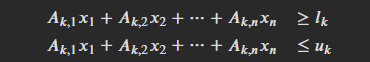

They express that by eating  𝑥1
  amount of food  𝐹1
 ,  𝑥2
  of food  𝐹2
  and so on, a person gets total amount of nutritient  𝑁𝑘
  within the desired limits. We add these constraints for each nutrient.

In [9]:
all_nutrients = [(row['name'], row['qmin'], row['qmax']) for _, row in df_nutrients.iterrows()]
print('All nutrients: \n\t', all_nutrients)

for (nk,l,u) in all_nutrients:
    # Just restrict ourselves to nutrient `nk`
    nut_terms = ( [ (row['Food'], row[nk]) for (_, row) in df_food_nutrients.iterrows() ])
    nut_lhs_expr = sum( [c*food_name_to_dec_var[name] for (name, c) in nut_terms])
    print(f'Constraints for nutrient: {nk}')
    print(f'\t {nut_lhs_expr} <= {u}')
    model += nut_lhs_expr <= u
    print(f'\t {nut_lhs_expr} >= {l}')
    model += nut_lhs_expr >= l 

All nutrients: 
	 [('Calories', 2000, 2500), ('Calcium', 800, 1600), ('Iron', 10, 30), ('Vit_A', 5000, 50000), ('Dietary_Fiber', 25, 100), ('Carbohydrates', 0, 300), ('Protein', 50, 100)]
Constraints for nutrient: Calories
	 277.4*x_1 + 358.2*x_2 + 25.8*x_3 + 81.4*x_4 + 15.1*x_5 + 78.1*x_6 + 121.2*x_7 + 115.1*x_8 + 242.1*x_9 <= 2500
	 277.4*x_1 + 358.2*x_2 + 25.8*x_3 + 81.4*x_4 + 15.1*x_5 + 78.1*x_6 + 121.2*x_7 + 115.1*x_8 + 242.1*x_9 >= 2000
Constraints for nutrient: Calcium
	 21.9*x_1 + 80.2*x_2 + 6.2*x_3 + 9.7*x_4 + 3.4*x_5 + 6.2*x_6 + 296.7*x_7 + 12.9*x_8 + 23.5*x_9 <= 1600
	 21.9*x_1 + 80.2*x_2 + 6.2*x_3 + 9.7*x_4 + 3.4*x_5 + 6.2*x_6 + 296.7*x_7 + 12.9*x_8 + 23.5*x_9 >= 800
Constraints for nutrient: Iron
	 1.8*x_1 + 2.3*x_2 + 0.6*x_3 + 0.2*x_4 + 0.1*x_5 + 0.4*x_6 + 0.1*x_7 + 16.8*x_8 + 2.3*x_9 <= 30
	 1.8*x_1 + 2.3*x_2 + 0.6*x_3 + 0.2*x_4 + 0.1*x_5 + 0.4*x_6 + 0.1*x_7 + 16.8*x_8 + 2.3*x_9 >= 10
Constraints for nutrient: Vit_A
	 77.4*x_1 + 3055.2*x_2 + 766.3*x_3 + 73.1*x_4 + 24.0*x

In [10]:

model.solve()

# Each of the variables is printed with it's resolved optimum value
for f in food_names:
    v = food_name_to_dec_var[f]
    print(f' {f} --> {v.varValue} servings')
print(f'Cost: ${value(model.objective)}')

 Roasted Chicken --> 0.14891116 servings
 Spaghetti W/ Sauce --> 2.1551724 servings
 Tomato,Red,Ripe,Raw --> 0.0 servings
 Apple,Raw,W/Skin --> 0.0 servings
 Grapes --> 0.0 servings
 Chocolate Chip Cookies --> 12.331421 servings
 Lowfat Milk --> 1.8450934 servings
 Raisin Brn --> 0.0 servings
 Hotdog --> 0.0 servings
Cost: $2.6004339584000005
time: 141 ms (started: 2024-10-19 20:10:46 -07:00)
